# uproot / awkward / pandas File Reading Example
This notebook demonstrates how to use a mostly pythonic workflow, involving `uproot` , `awkward` and `panda dataframes` to read and analyze data stored in `CAF` files. It covers the following topics:

- Reading a CAF file using `uproot` and saving all accessible branches into `awkward` arrays
  - Renaming, organizing and flattening some of the arrays, and plotting the contents (in the example, muon (anti)neutrino energy spectra) with `matplotlib`
  
- Demonstrating how to create flat arrays for deeper nested, not fully splitted branches not immediately accessible with `uproot`:
  - Reading the CAF tree with `pyROOT`
  - Filtering and plotting with `pandas` and `matplotlib` 

### Importing uproot / awkward, reading CAF, creating arrays

In [1]:
import uproot
from uproot.interpretation import objects, jagged, numerical
import matplotlib.pyplot as plt
import mplhep
mplhep.style.use("CMS")
import awkward as ak

tree = uproot.open("../../../work_folder/MicroProdN4p1_NDComplex_FHC.caf.full.light.spineonly.0002459.CAF.root")["cafTree"]

safe = []

for name, branch in tree.items():
    interp = branch.interpretation

    # Skip any C++ object interpretation
    if isinstance(interp, objects.AsObjects):
        continue

    # Keep plain numeric branches
    if isinstance(interp, numerical.AsDtype):
        safe.append(name)

    # Keep jagged numeric branches
    if isinstance(interp, jagged.AsJagged) and \
       isinstance(interp.content, numerical.AsDtype):
        safe.append(name)

print("Reading", len(safe), "branches")
arrays = tree.arrays(safe, library="ak")

## Uncomment to print the names of the columns
# for col in arrays.fields:
#     print(col)


Reading 325 branches


### Flattening and renaming arrays for flotting

In [2]:
renamed_arrays = ak.zip({
    "nu_energy": arrays["rec/mc/mc.nu/mc.nu.E"],
    "nu_pdg": arrays["rec/mc/mc.nu/mc.nu.pdg"]
})
for i, spill in enumerate(renamed_arrays[:0]):  # first 2 spills
    print(f"Spill {i}:")
    for nu in spill:
        print("  ", nu)

### Simple plotting

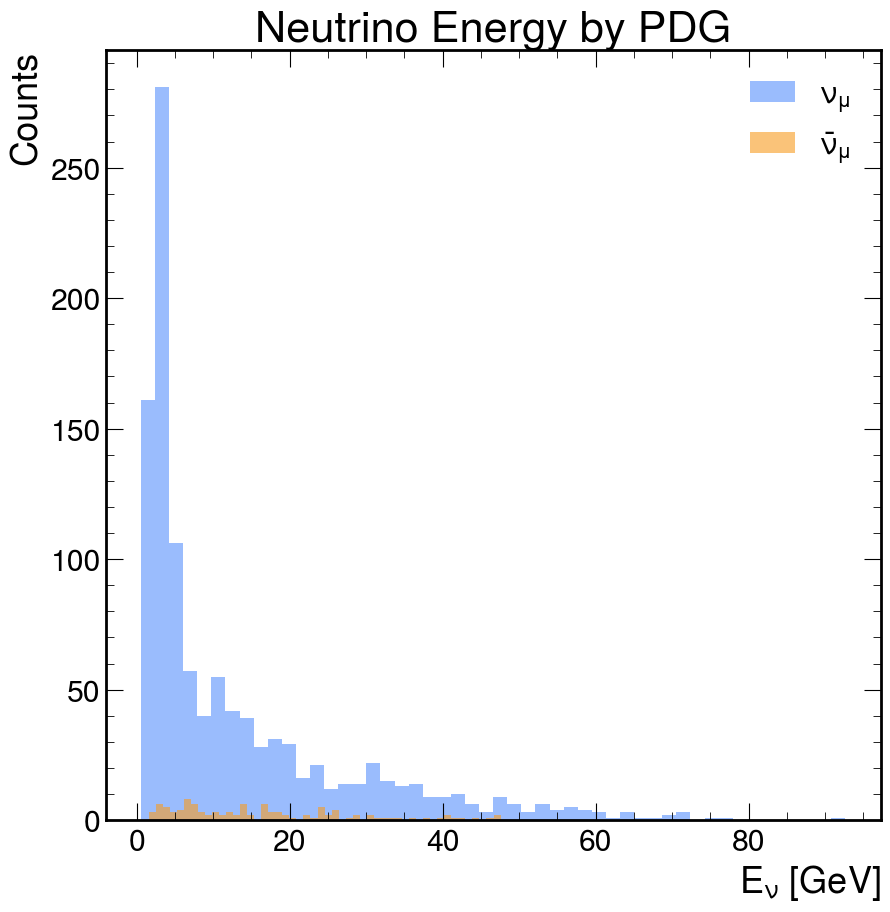

In [3]:
flat_nu = ak.flatten(renamed_arrays)

mu_nu = flat_nu[flat_nu.nu_pdg == 14]
antimu_nu = flat_nu[flat_nu.nu_pdg == -14]

plt.hist(ak.to_numpy(mu_nu.nu_energy), bins=50, alpha=0.6, label=r'$\nu_\mu$')
plt.hist(ak.to_numpy(antimu_nu.nu_energy), bins=50, alpha=0.6, label=r'$\bar{\nu}_\mu$')

plt.xlabel(r"$E_{\nu}$ [GeV]")
plt.ylabel("Counts")
plt.legend()
plt.title("Neutrino Energy by PDG")
plt.show()

## Mixed pyROOT / panda workflow for deep non-split branches not accessible to uproot

### Importing modules and dictionaries for pyROOT

In [4]:
import ROOT
import pandas as pd

ROOT.gSystem.AddDynamicPath("../../build/_deps/duneanaobj-build/duneanaobj/StandardRecord")
ROOT.gSystem.Load("libduneanaobj_StandardRecord")

0

### Reading tree 

In [5]:
f = ROOT.TFile("../../../work_folder/MicroProdN4p1_NDComplex_FHC.caf.full.light.spineonly.0002459.CAF.root")
tree = f.Get("cafTree")
# tree.Print() # Uncomment to print the tree

Warning in <TClass::Init>: no dictionary for class genie::NtpMCEventRecord is available
Warning in <TClass::Init>: no dictionary for class genie::NtpMCRecordI is available
Warning in <TClass::Init>: no dictionary for class genie::NtpMCRecHeader is available
Warning in <TClass::Init>: no dictionary for class genie::EventRecord is available
Warning in <TClass::Init>: no dictionary for class genie::GHepRecord is available
Warning in <TClass::Init>: no dictionary for class genie::Interaction is available
Warning in <TClass::Init>: no dictionary for class genie::InitialState is available
Warning in <TClass::Init>: no dictionary for class genie::Target is available
Warning in <TClass::Init>: no dictionary for class genie::ProcessInfo is available
Warning in <TClass::Init>: no dictionary for class genie::Kinematics is available
Warning in <TClass::Init>: no dictionary for class genie::XclsTag is available
Warning in <TClass::Init>: no dictionary for class genie::KPhaseSpace is available
Warni

### Filling arrays

In [6]:
numu_prim_props = {"numu_prim_pdg": [], "numu_prim_p": []}
for entry in tree:
    for nu in entry.rec.mc.nu:
        if nu.pdg != 14:
            continue
        for p in nu.prim:
            numu_prim_props["numu_prim_pdg"].append(p.pdg)
            numu_prim_props["numu_prim_p"].append(p.p.Mag())

# print(numu_prim_props) # Uncomment to print the properties

### Generating panda Dataframe and filtering for selected pdg's

In [7]:
df = pd.DataFrame({"numu_prim_pdg": numu_prim_props["numu_prim_pdg"], "numu_prim_p": numu_prim_props["numu_prim_p"]})
selected_pdgs = [13, 211, -211, 111, 2212, 2112]
df_filtered = df[df["numu_prim_pdg"].isin(selected_pdgs)]

### Simple plotting

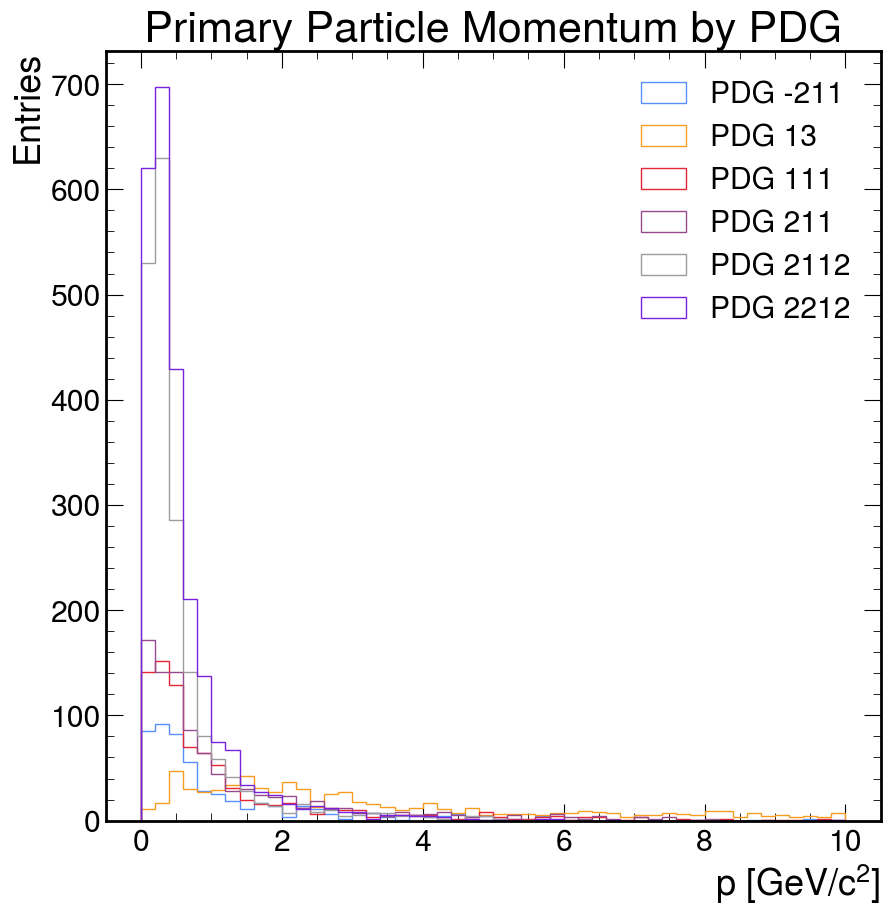

In [8]:
for pdg, group in df_filtered.groupby("numu_prim_pdg"):
    plt.hist(group["numu_prim_p"], 
             bins=50, 
             histtype="step", 
             label=f"PDG {pdg}",
             range=(0, 10))

plt.xlabel(r"p [GeV/$c^2$]")
plt.ylabel("Entries")
plt.title("Primary Particle Momentum by PDG")
plt.legend()
plt.show()